# Phase 2 — Chunk 2: Late-delivery classification

**Business question:** among orders eventually delivered, which purchases will arrive after the promised calendar date? The prediction point is immediately after checkout and payment submission. Same-date delivery is on time.

This is the **classification review checkpoint**. We use the primary training population and its five expanding-time validation folds. The later-period test set is reserved for Chunk 5. These are model-selection results, not final generalisation estimates.

Shared definitions: [data preparation](data_prep.ipynb) and [assumptions](../../docs/phase2_assumptions.md). Training implementation: `phase2_classification.py` at the repository root. This notebook displays saved evidence and exports report figures; enable `RERUN_TRAINING` to reproduce training.

In [1]:
from pathlib import Path
import json
import sys

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "phase2_classification.py").is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from IPython.display import display
from phase2_classification import run_classification, metrics

OUTPUT = ROOT / "results/phase2/classification"
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

## 1. Preprocessing and experiment design

- Use the 18 candidate predictors from the versioned feature specification. IDs, labels, delivery dates and split columns never enter the model.
- Fit median imputation and categorical encoding separately inside each fold's Pipeline. Use one-hot encoding for both linear and tree models so nominal categories are not assigned an arbitrary numeric order. Unseen categories are ignored by the fitted encoder.
- Scale numeric inputs for logistic regression and represent purchase hour by sine/cosine. Trees use unscaled numeric inputs and raw hour. These are fixed modelling choices, not choices based on the later test set.
- Each validation block has 7,601 orders. Training uses only earlier purchases delivered before that block starts. Validation purchases end before 2018-03-27, preserving the agreed 60-day maturity gap. Recent primary training rows are available for the final fit in Chunk 5.
- All experiments use seed 42. Random forests have 200 trees, `max_features="sqrt"`, and four worker threads. Logistic regression uses L2 regularisation through `C` and a maximum of 3,000 iterations.

### Bounded tuning candidates

| Approach | Starting point | Variants |
|---|---|---|
| Prior baseline | Constant training-fold late probability | None |
| Linear | Logistic regression, C=1, no class weighting | C=0.1; C=10; C=1 with balanced weights |
| Tree | Unrestricted decision tree | Depth 6/leaf 50; depth 12/leaf 20; depth 12/leaf 20 with balanced weights |
| Tree | Random forest with unrestricted depth/leaf 1 | Depth 12/leaf 20; unrestricted depth/leaf 20; the latter with balanced subsample weights |

The tree and forest are two algorithms within the **same tree-based family**. Explicit voting across the linear and tree families is Chunk 4. This compact search does not establish that these are globally optimal settings.

## 2. Run validation

Selection uses **mean per-fold average precision**, computed by `average_precision_score`. We label this PR-AUC (average precision); it is not trapezoidal integration of the precision–recall curve. Average precision depends on prevalence, so show every fold and its baseline.

After selecting settings within each algorithm, repeat that selected configuration without `payment_type` and `max_installments`. This is a paired sensitivity check with the same parameters, not a separately exhaustive tuning exercise. The highest mean validation average precision among all tested configurations becomes the provisional choice. Exact ties retain the earlier candidate in the declared search order.

Set `RERUN_TRAINING=True` to train and replace the saved results, or run `python phase2_classification.py` from the repository root. The default reads the completed run and verifies its input and implementation hashes before presenting results.

In [2]:
import hashlib

RERUN_TRAINING = False  # True reproduces the full bounded CV search.
if RERUN_TRAINING:
    summary, threshold_results, selection = run_classification(ROOT)
else:
    selection = json.loads((OUTPUT / "selection.json").read_text())
    for name, expected in selection["input_sha256"].items():
        assert hashlib.sha256((ROOT / "data" / name).read_bytes()).hexdigest() == expected, "Inputs changed; rerun training"
    assert hashlib.sha256((ROOT / "phase2_classification.py").read_bytes()).hexdigest() == selection["implementation_sha256"], "Implementation changed; rerun training"
    summary = pd.read_csv(OUTPUT / "cv_summary.csv", index_col="candidate", float_precision="round_trip")
    threshold_results = pd.read_csv(OUTPUT / "threshold_metrics.csv", float_precision="round_trip")
folds = pd.read_csv(OUTPUT / "folds.csv")
fold_metrics = pd.read_csv(OUTPUT / "cv_metrics.csv", float_precision="round_trip")
# Preserve exact score boundaries used by the selected >= threshold rule.
oof = pd.read_csv(OUTPUT / "selected_validation_predictions.csv", float_precision="round_trip")
display(folds)
print("Selected:", selection["selected_candidate"])
print("Family winners for later ensemble work:", selection["family_winners"])

,fold,fit_orders,validation_orders,validation_start,validation_end,latest_training_outcome,late_rate
0,0,23695,7601,2017-09-22 12:22:40,2017-11-14 12:58:20,2017-09-22 12:16:09,0.0408
1,1,30987,7601,2017-11-14 13:25:40,2017-12-11 08:56:47,2017-11-14 13:12:29,0.1383
2,2,36197,7601,2017-12-11 09:04:24,2018-01-20 11:38:30,2017-12-10 22:20:02,0.0478
3,3,45014,7601,2018-01-20 11:39:20,2018-02-22 20:53:14,2018-01-20 11:36:26,0.0992
4,4,52198,7601,2018-02-22 21:16:34,2018-03-26 23:50:49,2018-02-22 21:14:23,0.2073


Selected: logistic_c01
Family winners for later ensemble work: {'linear': 'logistic_c01', 'tree_based': 'forest_depth12_no_payment'}


## 3. Compare candidates and folds

The following precision, recall, F1 and MCC values use the default 0.5 threshold. Ranking metrics (average precision and ROC-AUC) do not depend on that alert threshold. A strong ranking model can still miss most late orders at 0.5; threshold choice is evaluated separately below.

,mean_average_precision,std_average_precision,mean_roc_auc,mean_precision_at_05,mean_recall_at_05,mean_f1_at_05,mean_mcc_at_05,seconds
candidate,,,,,,,,
logistic_c01,0.1808,0.1229,0.6384,0.0000,0.0000,0.0000,0.0000,1.3151
logistic_c01_no_payment,0.1808,0.1228,0.6361,0.0000,0.0000,0.0000,0.0000,1.1558
logistic_baseline,0.1698,0.1214,0.6146,0.0000,0.0000,0.0000,-0.0019,1.3883
forest_depth12_no_payment,0.1693,0.1122,0.6328,0.0000,0.0000,0.0000,0.0000,11.4894
forest_depth12,0.1690,0.1113,0.6319,0.0000,0.0000,0.0000,0.0000,12.9040
logistic_c10,0.1665,0.1212,0.6046,0.1176,0.0030,0.0057,0.0129,1.6654
forest_leaf20,0.1662,0.1071,0.6282,0.0000,0.0000,0.0000,0.0000,23.3510
forest_balanced,0.1634,0.1068,0.6264,0.1995,0.0527,0.0786,0.0512,23.9935
logistic_balanced,0.1596,0.1115,0.5995,0.1640,0.4309,0.1823,0.0937,2.5856


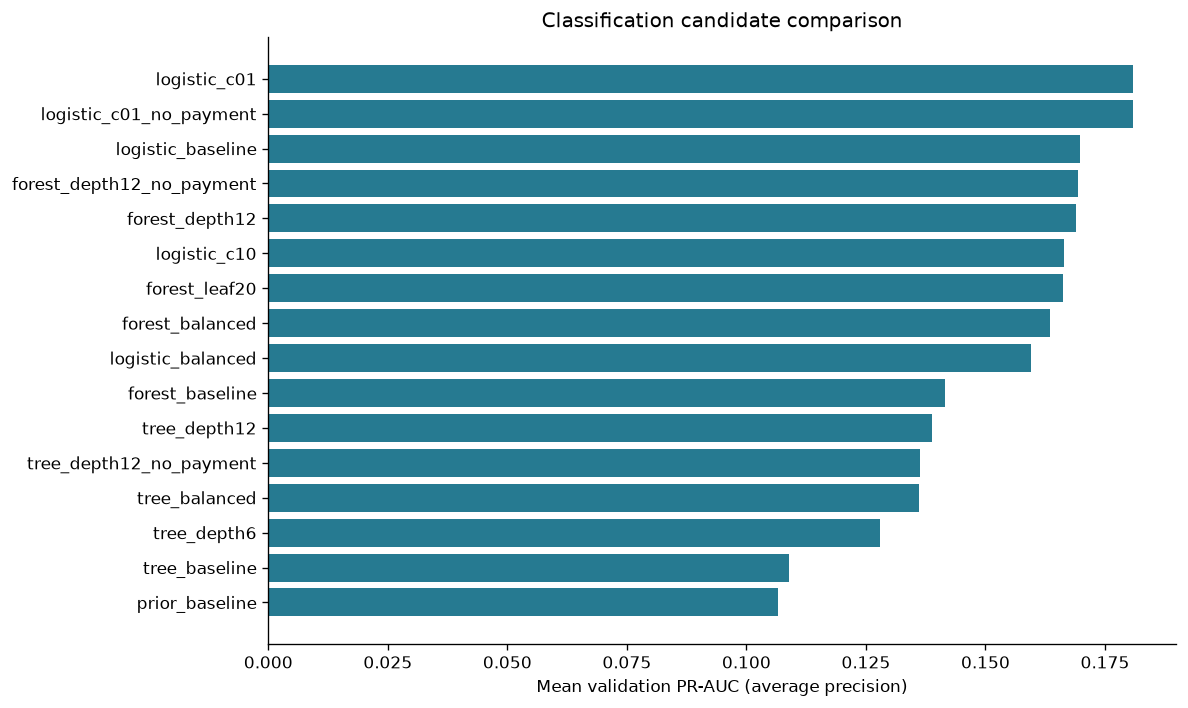

In [3]:
display(summary)
fig, ax = plt.subplots(figsize=(10, 6))
ordered = summary.sort_values("mean_average_precision")
ax.barh(ordered.index, ordered["mean_average_precision"], color="#267a91")
ax.set(xlabel="Mean validation PR-AUC (average precision)", title="Classification candidate comparison")
fig.tight_layout()
fig.savefig(OUTPUT / "candidate_comparison.png", bbox_inches="tight")
plt.show()

,candidate,fold,validation_late_rate,average_precision,roc_auc
0,prior_baseline,0,0.0408,0.0408,0.5000
1,prior_baseline,1,0.1383,0.1383,0.5000
2,prior_baseline,2,0.0478,0.0478,0.5000
3,prior_baseline,3,0.0992,0.0992,0.5000
4,prior_baseline,4,0.2073,0.2073,0.5000
10,logistic_c01,0,0.0408,0.0729,0.6686
11,logistic_c01,1,0.1383,0.1857,0.6024
12,logistic_c01,2,0.0478,0.0654,0.5503
13,logistic_c01,3,0.0992,0.2141,0.6936
14,logistic_c01,4,0.2073,0.3660,0.6772


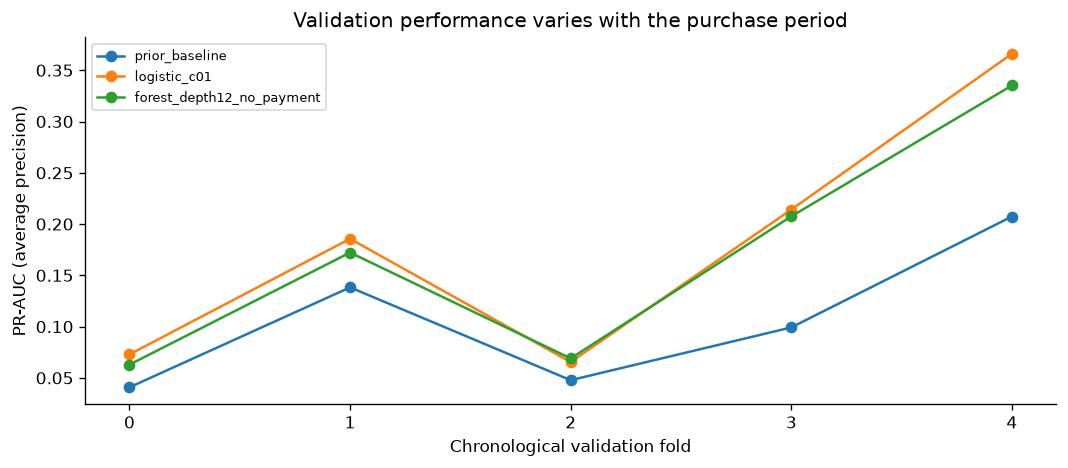

In [4]:
selected = selection["selected_candidate"]
comparison = fold_metrics[fold_metrics["candidate"].isin(
    ["prior_baseline", *selection["family_winners"].values()])]
display(comparison[["candidate", "fold", "validation_late_rate", "average_precision", "roc_auc"]])
fig, ax = plt.subplots(figsize=(9, 4))
for name, group in comparison.groupby("candidate", sort=False):
    ax.plot(group["fold"], group["average_precision"], marker="o", label=name)
ax.set(xlabel="Chronological validation fold", ylabel="PR-AUC (average precision)",
       title="Validation performance varies with the purchase period", xticks=range(5))
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT / "fold_comparison.png", bbox_inches="tight")
plt.show()

## 4. Payment-feature sensitivity

Payment rows have no recording timestamps. We reasonably assume submitted payment details are available at checkout, but the all-row aggregation is uncertain. The comparison below measures whether omitting those two features changes validation performance. It cannot prove or disprove historical availability.

In [5]:
sensitivity = []
for name, configuration in selection["candidates"].items():
    if "paired_with" in configuration:
        paired = configuration["paired_with"]
        with_ap = summary.loc[paired, "mean_average_precision"]
        without_ap = summary.loc[name, "mean_average_precision"]
        sensitivity.append({"algorithm": configuration["algorithm"], "with_payment_candidate": paired,
                            "with_payment_ap": with_ap, "without_payment_ap": without_ap,
                            "delta_without_minus_with": without_ap - with_ap})
sensitivity = pd.DataFrame(sensitivity)
display(sensitivity)
sensitivity.to_csv(OUTPUT / "payment_sensitivity.csv", index=False)

,algorithm,with_payment_candidate,with_payment_ap,without_payment_ap,delta_without_minus_with
0,linear,logistic_c01,0.1808,0.1808,-0.0001
1,tree,tree_depth12,0.1389,0.1364,-0.0025
2,forest,forest_depth12,0.1690,0.1693,0.0004


## 5. Choose an alert threshold

Use the selected model's validation predictions to maximise **Matthews correlation coefficient (MCC)** over all distinct probability boundaries. When MCC ties, prefer fewer alerts. We do not have intervention costs or an operations capacity limit, so this is a statistical starting point rather than a proven business-optimal threshold.

The threshold is chosen and measured on the **same validation predictions** used during model development. The tuned MCC, confusion matrix, and precision/recall are therefore descriptive selection results, not independent estimates. The untouched later test supplies the final assessment in Chunk 5. Pooling the validation folds also combines different seasonal class rates.

,rule,threshold,average_precision,roc_auc,precision,recall,f1,mcc,true_negative,false_positive,false_negative,true_positive
0,default_0.5,0.5000,0.1809,0.6343,0.0000,0.0000,0.0000,0.0000,33951,0,4054,0
1,validation_selected_mcc,0.0800,0.1809,0.6343,0.2658,0.1771,0.2126,0.1426,31968,1983,3336,718


,fold,average_precision,roc_auc,precision,recall,f1,mcc,true_negative,false_positive,false_negative,true_positive
0,0,0.0729,0.6686,0.0933,0.1129,0.1022,0.0605,6951,340,275,35
1,1,0.1857,0.6024,0.3214,0.0257,0.0476,0.0561,6493,57,1024,27
2,2,0.0654,0.5503,0.0761,0.1543,0.1019,0.0435,6558,680,307,56
3,3,0.2141,0.6936,0.2939,0.2440,0.2667,0.1952,6405,442,570,184
4,4,0.3660,0.6772,0.4727,0.2640,0.3388,0.2369,5561,464,1160,416


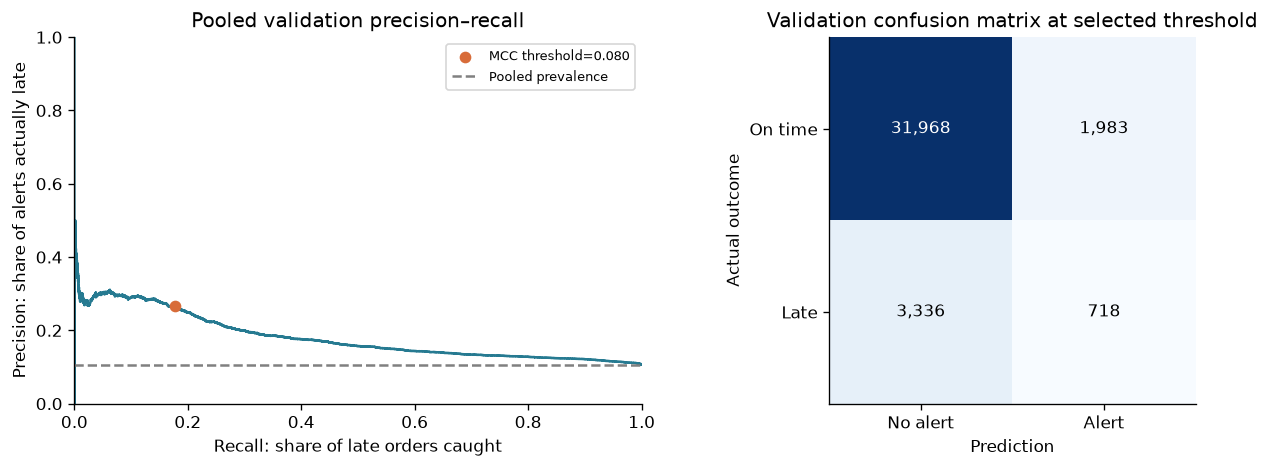

In [6]:
display(threshold_results)
chosen_threshold = selection["selected_threshold"]
by_fold = []
for fold, group in oof.groupby("fold"):
    by_fold.append({"fold": fold, **metrics(group["is_late"], group["probability"], chosen_threshold)})
display(pd.DataFrame(by_fold))
pd.DataFrame(by_fold).to_csv(OUTPUT / "selected_threshold_by_fold.csv", index=False)

precision, recall, thresholds = precision_recall_curve(oof["is_late"], oof["probability"])
chosen = threshold_results.iloc[1]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(recall, precision, color="#267a91")
axes[0].scatter([chosen["recall"]], [chosen["precision"]], color="#d86c39", zorder=3,
                label=f"MCC threshold={chosen_threshold:.3f}")
axes[0].axhline(oof["is_late"].mean(), color="grey", linestyle="--", label="Pooled prevalence")
axes[0].set(xlabel="Recall: share of late orders caught", ylabel="Precision: share of alerts actually late",
            title="Pooled validation precision–recall", xlim=(0, 1), ylim=(0, 1))
axes[0].legend(fontsize=8)
matrix = np.array([[chosen["true_negative"], chosen["false_positive"]],
                   [chosen["false_negative"], chosen["true_positive"]]], dtype=int)
axes[1].imshow(matrix, cmap="Blues")
for (row, col), value in np.ndenumerate(matrix):
    axes[1].text(col, row, f"{value:,}", ha="center", va="center",
                 color="white" if value > matrix.max()/2 else "black")
axes[1].set(xticks=[0, 1], xticklabels=["No alert", "Alert"], yticks=[0, 1],
            yticklabels=["On time", "Late"], xlabel="Prediction", ylabel="Actual outcome",
            title="Validation confusion matrix at selected threshold")
fig.tight_layout()
fig.savefig(OUTPUT / "threshold_review.png", bbox_inches="tight")
plt.show()

## 6. Review checkpoint and limits

Review the candidate comparison, payment sensitivity, and missed orders versus false alerts before regression starts. Retain the linear and tree-family winning configurations for the explicit voting comparison in Chunk 4.

These experiments concern eventual delivered orders in the historical Olist sample. They do not quantify cancellation or non-delivery risk. Source-field timing remains an assumption; temporal validation has residual outcome censoring despite the maturity gap. The full-dataset Phase 1 EDA already informed the candidate features, and repeated validation use makes the reported scores model-selection evidence. We have not fitted a final production model, evaluated the primary test, or run the secondary random benchmark in this chunk.

`selection.json` records exact candidate settings, package versions, seeds, and input hashes. CSV evidence and the three figures are in `results/phase2/classification/`.

In [7]:
assert not selection["primary_test_evaluated"]
assert not selection["final_model_fitted"]
assert len(oof) == selection["validation_orders"]
assert oof["order_id"].is_unique
print("Chunk 2 is ready for review; final holdout evaluation remains in Chunk 5.")

Chunk 2 is ready for review; final holdout evaluation remains in Chunk 5.
